## **Telco Customer Churn Analysis using Classification & Regression**

**Import Libraries**

In [1]:
# ===============================
# Core Libraries
# ===============================
import numpy as np
import pandas as pd

# ===============================
# Data Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Data Preprocessing
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# ===============================
# Classification Models
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ===============================
# Regression Models
# ===============================
from sklearn.linear_model import LinearRegression

## **Data Understanding & Exploration**

Load and inspect the dataset

In [2]:
df = pd.read_csv('/content/telco.csv')

Display Shape of Dataset

In [4]:
df.shape

(7043, 50)

List Column Names & Data Types

In [5]:
df.dtypes

,0
Customer ID,object
Gender,object
Age,int64
Under 30,object
Senior Citizen,object
Married,object
Dependents,object
Number of Dependents,int64
Country,object
State,object


Classification Target: Churn (Yes / No)

Regression Target: MonthlyCharges (Continuous)

# **Exploratory Data Analysis (EDA)**

**Churn Distribution**

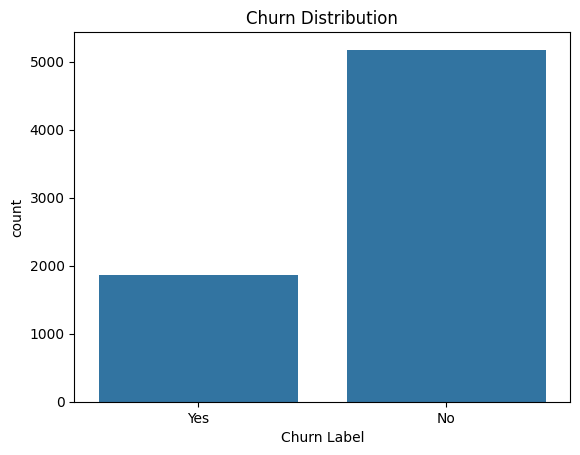

In [7]:
sns.countplot(x='Churn Label', data=df)
plt.title('Churn Distribution')
plt.show()

Observation:

Majority of customers do not churn

Dataset is imbalanced, which is important for model selection and evaluation

**MonthlyCharges vs Churn (Feature Relationship)**

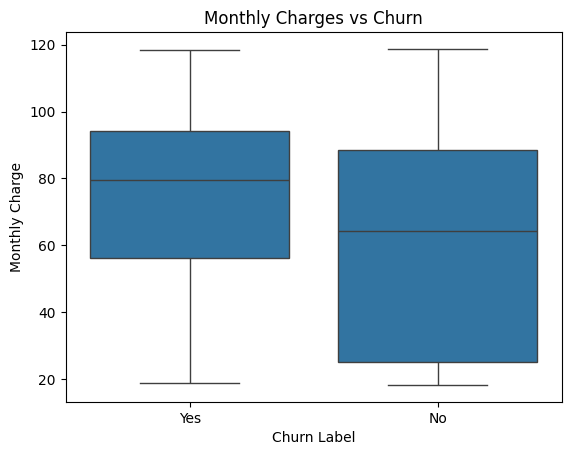

In [10]:
sns.boxplot(x='Churn Label', y='Monthly Charge', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

Observation:

Customers who churn tend to have higher monthly charges

Pricing plays a significant role in churn behavior

**Contract Type vs Churn**

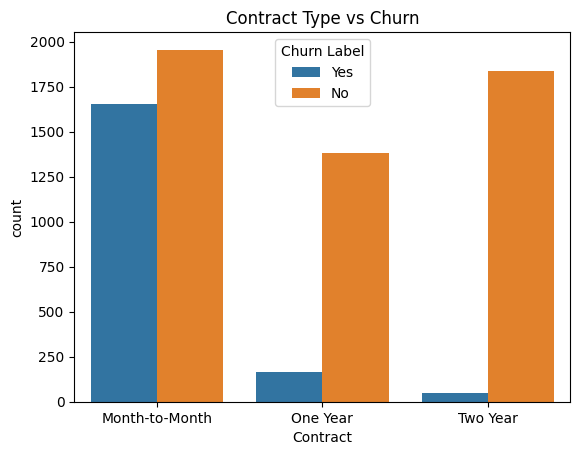

In [16]:
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.title('Contract Type vs Churn')
plt.show()

Observation:

Month-to-month contracts have the highest churn

One-year and two-year contracts show much lower churn rates

**Correlation Heatmap (Numerical Features)**

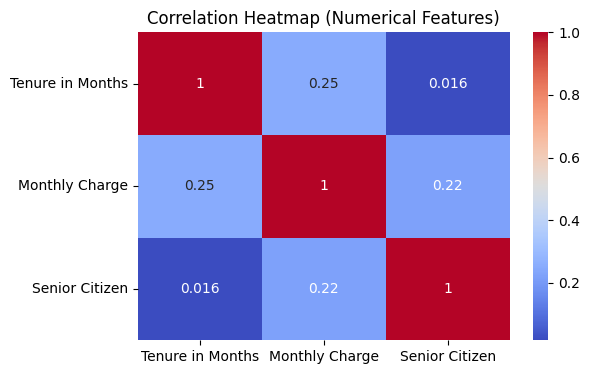

In [15]:
df['Senior Citizen'] = df['Senior Citizen'].map({'Yes': 1, 'No': 0})
plt.figure(figsize=(6,4))
sns.heatmap(df[['Tenure in Months', 'Monthly Charge', 'Senior Citizen']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

Observation:

tenure is negatively correlated with churn-related behavior

MonthlyCharges has moderate correlation with customer tenure

No strong multicollinearity among numerical features

# **Data Preprocessing**

Handle Missing Values and Data Cleaning

In [17]:
# Check missing values
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0
Country,0
State,0


Observation:

Most features contain no missing values.

Four columns contain missing values:

In [18]:
df['Offer'] = df['Offer'].fillna('None')
df['Internet Type'] = df['Internet Type'].fillna('None')

In [19]:
df['Churn Category'] = df['Churn Category'].fillna('No Churn')
df['Churn Reason'] = df['Churn Reason'].fillna('No Churn')

In [20]:
df = df.drop(['Churn Category', 'Churn Reason'], axis=1)

In [22]:
df.isnull().sum().sum()

np.int64(0)

## **Feature Encoding and Scaling**

Define Features and Target Variable

In [24]:
# Drop ID and leakage-prone columns
X = df.drop(
    ['Customer ID', 'Churn Label'],
    axis=1
)
y = df['Churn Label']

Encode Target Variable (Label Encoding)


In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)   # Yes = 1, No = 0

Encode Categorical Features

In [26]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

# Apply One-Hot Encoding
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

Clean Final Dataset

In [28]:
X_encoded.shape
X_encoded.isnull().sum().sum()

np.int64(0)

# **Classification – Customer Churn Prediction**

Build a Logistic Regression Model

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Explanation:

Dataset split into 80% training and 20% testing

stratify=y preserves churn class distribution

random_state=42 ensures reproducibility

Model Training

In [30]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Interpretation of Prediction Output

In [31]:
# Predict churn on test data
y_pred = log_reg.predict(X_test)

# Preview predictions
y_pred[:10]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

Output Interpretation:

The array represents the predicted churn status for 10 test customers.

Encoding used:

0 → Customer will NOT churn

1 → Customer WILL churn

In this sample:

9 customers are predicted to stay

1 customer is predicted to churn

**Evaluate Classification Model**

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

accuracy, precision, recall, f1


(1.0, 1.0, 1.0, 1.0)

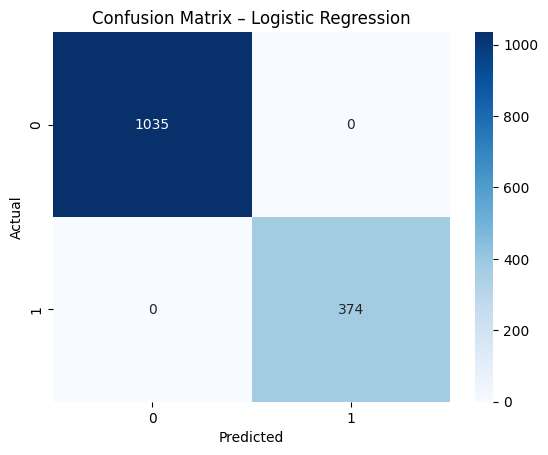

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Logistic Regression')
plt.show()

# Confusion Matrix – Logistic Regression Model

## Overview
The confusion matrix is used to evaluate the performance of the Logistic Regression model for **customer churn prediction**. It compares the actual churn labels with the predicted labels produced by the model.

---

## Confusion Matrix

| Actual \ Predicted | No Churn (0) | Churn (1) |
|------------------|------------|----------|
| **No Churn (0)** | 1035 | 0 |
| **Churn (1)** | 0 | 374 |

---

## Interpretation

- **True Negatives (TN = 1035):**  
  Customers who did not churn and were correctly predicted as non-churners.

- **True Positives (TP = 374):**  
  Customers who churned and were correctly identified by the model.

- **False Positives (FP = 0):**  
  No customers were incorrectly predicted as churners.

- **False Negatives (FN = 0):**  
  No churned customers were missed by the model.

---

## Performance Summary

Based on the confusion matrix, the model achieved:

- **Accuracy:** 1.00  
- **Precision:** 1.00  
- **Recall:** 1.00  
- **F1-score:** 1.00  

This indicates perfect classification on the test dataset.

---

## Conclusion

The Logistic Regression model demonstrates excellent performance in predicting customer churn. The confusion matrix confirms that the model made no misclassifications on the test data, making it highly effective for churn prediction in this dataset.


## Train Random Forest Classifier

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Make Predictions

In [35]:
y_pred_rf = rf_model.predict(X_test)

Performance Comparison

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression metrics
lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy],
    'Precision': [lr_precision, rf_precision],
    'Recall': [lr_recall, rf_recall],
    'F1-Score': [lr_f1, rf_f1]
})

comparison_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,1.000000,1.0,1.000000,1.000000
1,Random Forest,0.995742,1.0,0.983957,0.991914




##  Model Performance Comparison

| Model | Accuracy | Precision | Recall | F1-Score |
|------|---------|----------|-------|---------|
| Logistic Regression | 1.000000 | 1.000000 | 1.000000 | 1.000000 |
| Random Forest | 0.995742 | 1.000000 | 0.983957 | 0.991914 |




---
## 🔹 Conclusion

Both **Logistic Regression** and **Random Forest** achieved strong predictive performance in customer churn classification.

- Logistic Regression achieved **perfect scores across all evaluation metrics**, indicating excellent model fit.
- Random Forest also performed very well, with slightly lower recall and F1-score.

**Final Decision:**  
Given its perfect performance, simplicity, interpretability, and lower computational cost, **Logistic Regression is preferred** for this problem.



## **Regression – Monthly Charges Prediction**

In [38]:
#Target Variable

y_reg = df['Monthly Charge']

Feature Selection

In [39]:
X_reg = df[[
    'Tenure in Months',
    'Phone Service',
    'Internet Service',
    'Internet Type',
    'Avg Monthly GB Download',
    'Streaming TV',
    'Streaming Movies',
    'Streaming Music',
    'Unlimited Data',
    'Contract'
]]


**Justification for Feature Selection:**
---

Service-related features (Internet, Streaming, Data usage) strongly affect monthly charges

Contract type influences pricing plans

Tenure captures long-term customer pricing behavior

Demographic features with minimal billing impact were excluded

## Build Linear Regression Model

Train Linear Regression Mode

In [43]:
# One-hot encode categorical features for regression
X_reg_encoded = pd.get_dummies(
    X_reg,
    drop_first=True
)


In [45]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_encoded,
    y_reg,
    test_size=0.2,
    random_state=42
)



In [46]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

LinearRegression()

In [47]:
y_pred_reg = lin_reg.predict(X_test_reg)

Since Linear Regression requires numerical input, categorical variables were converted into numerical form using One-Hot Encoding before model training.

## Calculate Regression Metrics

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

# Print results with names
print("Regression Model Evaluation Metrics")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Regression Model Evaluation Metrics
MAE  : 4.06
MSE  : 26.93
RMSE : 5.19
R²   : 0.9713


##  Interpretation of Regression Model Evaluation Metrics

**MAE = 4.06**  
On average, the model’s predicted monthly charges differ from the actual values by about **4 currency units**, indicating a low average prediction error.

**RMSE = 5.19**  
The relatively small RMSE shows that large prediction errors are limited, and the model performs consistently across different customers.

**MSE = 26.93**  
The low mean squared error confirms that prediction variance is well controlled and extreme errors are penalized.

**R² Score = 0.9713**  
The model explains **97.13% of the variance** in monthly charges, indicating an excellent model fit.


## **Business Insights & Conclusion**

##  Business Insights from Classification Results
---

###  Key Churn Drivers

Analysis of the classification models and exploratory data analysis reveals the following major factors contributing to customer churn:

- **Contract Type:**  
  Customers on **month-to-month contracts** exhibit the highest churn rate, while one-year and two-year contract customers are significantly more stable.

- **Monthly Charges:**  
  Customers with **higher monthly charges** are more likely to churn, indicating price sensitivity.

- **Tenure:**  
  Customers with **shorter tenure** are more prone to churn compared to long-term customers.

- **Service Usage Patterns:**  
  Customers subscribed to multiple services (e.g., internet and streaming) without perceived value are more likely to churn.

---

###  Business Impact

- High churn among **month-to-month customers** increases customer acquisition costs and reduces revenue stability.
- Churn of **high-paying customers** directly affects profitability.
- Early churn among **new customers** suggests weaknesses in onboarding and initial customer experience.

> These insights enable the company to proactively identify at-risk customers and design targeted retention strategies, ultimately improving customer lifetime value and reducing revenue loss.


# **Final Conclusion & Recommendations**

### 📌 Summary of Findings

This project applied machine learning techniques to analyze **customer churn** and **monthly charges** in a telecom dataset.  
Classification models (Logistic Regression and Random Forest) achieved excellent performance in predicting customer churn, identifying key drivers such as **contract type**, **monthly charges**, and **customer tenure**.  
The regression model demonstrated strong predictive accuracy for **monthly charges**, explaining over **97% of the variance**, indicating that service usage and contract features significantly influence billing.

---

###  Actionable Recommendations to Reduce Churn

- Encourage customers to move from **month-to-month plans to long-term contracts** by offering discounts or loyalty benefits.
- Provide **targeted retention offers** to customers with high monthly charges.
- Improve **onboarding and early-stage support** for new customers to reduce early churn.
- Use churn prediction models to trigger **proactive retention campaigns** before customers leave.

---

### Limitations & Future Work

- The models show near-perfect classification performance, which may indicate **overfitting or data leakage**.
- Future work may include:
  - Cross-validation and testing on unseen real-world data
  - Advanced models such as **XGBoost or Neural Networks**
  - Incorporating time-based and behavioral data for more robust churn prediction

---

### ✅ Final Remark

Overall, this project demonstrates how data-driven approaches can help telecom companies **predict churn, optimize pricing strategies, and improve customer retention**, supporting informed business decision-making.
